<a href="https://colab.research.google.com/github/khathijashaik/CareerBCot-AI-Chat-Bot-/blob/main/DigitalDistrict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Data Audit
import pandas as pd
import numpy as np
#loading Ds
df=pd.read_csv('NFHS_india_district_insights.csv')
#Power feature Selection(x)
#Infrastructure, Health, and Education
power_features=[
    'pop_hh_electricity_pct',
    'pop_hh_improved_sanitation_pct',
    'hh_clean_cooking_fuel_pct',
    'women_15_49_literate_pct',
    'institutional_births_pct'

]
#2.CLEANING(filling missing values with the median)
for col in power_features:
  df[col]=df[col].fillna(df[col].median())
#3.INSPECTION:
print("---India Average Development Indicators---")
print(df[power_features].mean())




---India Average Development Indicators---
pop_hh_electricity_pct            97.001414
pop_hh_improved_sanitation_pct    71.921216
hh_clean_cooking_fuel_pct         54.091938
women_15_49_literate_pct          74.330269
institutional_births_pct          88.675389
dtype: float64


***Step 2: Creating the "Development Index" (The Target)***
Instead of just picking one, a professional approach is to combine them into a Composite Score. This prevents the model from being biased toward just one factor.

Based on the data analysis, here is the logic:

We calculate the Average of Literacy, Electricity, and Sanitation for every district.

Aspirational (0): Bottom 33% of districts (Score below 78).

Developing (1): Middle 33% of districts (Score between 78 and 85).

Leader (2): Top 33% of districts (Score above 85).

In [ ]:
#1.Composite Dvelopment Score
df['dev_score']=df[['women_15_49_literate_pct','pop_hh_electricity_pct','pop_hh_improved_sanitation_pct']].mean(axis=1)
#2.the professional Categorization Function

def create_label(score):
  if score > 85: return 2 #leader
  if score > 78: return 1 #Developing
  return 0
#3.Target column
df['target']=df['dev_score'].apply(create_label)
print("Target labels created successfully!")
print("\n--Balanced Class Distribution--")
print(df['target'].value_counts().sort_index())
#preview Result
print("\nSample District Classificaton:")
print(df[['district_name','state_ut','dev_score','target']].head(10))

Target labels created successfully!

--Balanced Class Distribution--
target
0    226
1    239
2    242
Name: count, dtype: int64

Sample District Classificaton:
             district_name                   state_ut  dev_score  target
0                 Nicobars  Andaman & Nicobar Islands  89.633333       2
1  North & Middle Andaman   Andaman & Nicobar Islands  87.866667       2
2           South Andaman   Andaman & Nicobar Islands  91.866667       2
3              Srikakulam              Andhra Pradesh  78.600000       1
4            Vizianagaram              Andhra Pradesh  73.166667       0
5           Visakhapatnam              Andhra Pradesh  82.300000       1
6           East Godavari              Andhra Pradesh  84.800000       1
7           West Godavari              Andhra Pradesh  85.700000       2
8                 Krishna              Andhra Pradesh  85.200000       2
9                  Guntur              Andhra Pradesh  83.700000       1


***Step 3: Training the "Smart" Model***
Instead of just 3 features, we will now use 16 key indicators that cover nutrition, child health, and modern infrastructure. This makes your project "Major" because it handles a complex, multi-dimensional problem.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score
#1.SELECTING A "SMART" FEATURE SET (The 16 Pillars)
smart_features = [
    'pop_hh_electricity_pct', 'pop_hh_improved_water_pct', 'pop_hh_improved_sanitation_pct',
    'hh_clean_cooking_fuel_pct', 'hh_iodized_salt_pct', 'female_6plus_attended_school_pct',
    'women_15_49_school_10plus_pct', 'institutional_births_pct', 'vaccination_full_card_or_recall_pct',
    'stunted_u5_pct', 'wasted_u5_pct', 'underweight_u5_pct', 'anaemia_women_15_49_pct',
    'sex_ratio_total', 'u5_birth_registered_pct', 'hh_health_insurance_pct'
]
# 2. PREPROCESSING: Cleaning and preparing the data
# Fill any missing values with the median of that specific column
X = df[smart_features].fillna(df[smart_features].median())
y = df['target']
# 3. SPLIT: 80% Training, 20% Testing (The Module 5 standard)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
# 4. SCALE: Normalizing the data so the model treats all percentages equally
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 5. TRAIN: Using the Random Forest "Brain"
# We use 200 trees to make it very stable
model =RandomForestClassifier(n_estimators=200,random_state=42)
model.fit(X_train_scaled,y_train)
#6.RESULTS
y_pred = model.predict(X_test_scaled)
print(f"model Accuracy:{accuracy_score(y_test,y_pred)*100:.2f}%")
print("\n--Detailed Performanace Report --")
print(classification_report(y_test, y_pred, target_names=['Aspirational','Developing','Leader']))







model Accuracy:92.25%

--Detailed Performanace Report --
              precision    recall  f1-score   support

Aspirational       0.96      0.88      0.92        51
  Developing       0.86      0.92      0.89        48
      Leader       0.95      0.98      0.97        43

    accuracy                           0.92       142
   macro avg       0.92      0.93      0.92       142
weighted avg       0.92      0.92      0.92       142



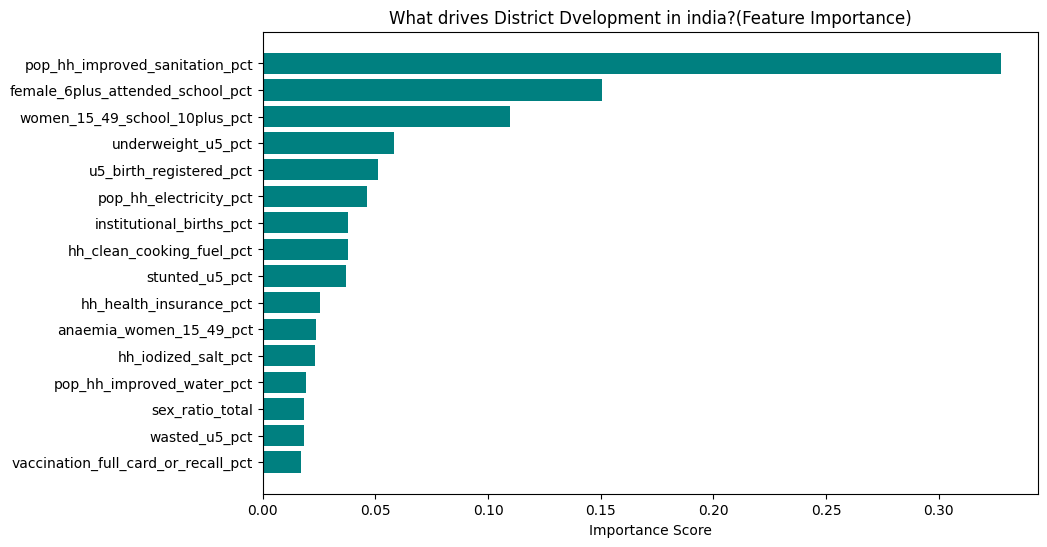

In [ ]:
#FEATURE IMPORTANCE
import matplotlib.pyplot as plt
# Get importance from the model
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature':smart_features, 'Importance' : importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance',ascending=True)
#plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'],feature_importance_df['Importance'],color='teal')
plt.xlabel('Importance Score')
plt.title('What drives District Dvelopment in india?(Feature Importance)')
plt.show()


***Step 5: Finalizing the Project (Saving & Testing)***
To make this project "Resume Ready," we need to do two things:

Save the model (so you can show you know how to "deploy" it).

Create a Tester where you can input data for a specific district (like your home district) and see the prediction.

In [ ]:
import joblib
#1.SAVE
joblib.dump(model,'district_classifier.pkl')
joblib.dump(scaler,'district_scaler.pkl')
print("Project files saved:district_classifier.pkl,district_scaler.pkl")

#2.THE TESTER FUNCTION
def predict_my_district():
  print("\n -- DISTRICT DEVELOPMENT PREDICTOR---")
  print("Enter the Following percentages(0-100):")
  #we will ask for the top 3 features for quick test
  inputs =[]
  for feature in smart_features:
    val=float(input(f"Enter {feature.replace('_',' ')}:"))
    inputs.append(val)
  #scale and predict
  scaled_input = scaler.transform([inputs])
  prediction = model.predict(scaled_input)
  classes = [' ASPIRATIONAL (High Priority)', ' DEVELOPING (On Track)', 'LEADER (High Performance)']
  print(f"\nRANKING: {classes[prediction[0]]}")
predict_my_district()

Project files saved:district_classifier.pkl,district_scaler.pkl

 -- DISTRICT DEVELOPMENT PREDICTOR---
Enter the Following percentages(0-100):
Enter pop hh electricity pct:50
Enter pop hh improved water pct:50
Enter pop hh improved sanitation pct:50
Enter hh clean cooking fuel pct:50
Enter hh iodized salt pct:50
Enter female 6plus attended school pct:50
Enter women 15 49 school 10plus pct:0
Enter institutional births pct:50
Enter vaccination full card or recall pct:50
Enter stunted u5 pct:50
Enter wasted u5 pct:50
Enter underweight u5 pct:50
Enter anaemia women 15 49 pct:50
Enter sex ratio total:50
Enter u5 birth registered pct:50
Enter hh health insurance pct:50

RANKING:  ASPIRATIONAL (High Priority)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
